# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

Propósito del proyecto: analizar el comportamiento de clientes de Megaline y determinar cuál tarifa, Surf o Ultimate, genera más ingresos.

Plan general de trabajo: cargar los datos, revisar su estructura, corregir problemas, calcular métricas mensuales por usuario, comparar ingresos por tarifa y probar hipótesis si el proyecto lo solicita.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv('datasets/megaline_calls.csv')
internet = pd.read_csv('datasets/megaline_internet.csv')
messages = pd.read_csv('datasets/megaline_messages.csv')
plans = pd.read_csv('datasets/megaline_plans.csv')
users = pd.read_csv('datasets/megaline_users.csv')

## Preparar los datos

En esta sección revisaré cada una de las tablas disponibles para comprender su estructura, identificar tipos de datos, valores ausentes y posibles problemas. Después realizaré las correcciones necesarias antes de calcular métricas mensuales por usuario y comparar el comportamiento entre tarifas.

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 272.0 bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


El DataFrame `plans` contiene dos filas, correspondientes a las tarifas Surf y Ultimate, y no presenta valores ausentes. Los tipos de datos son adecuados para el análisis. Se observa que la columna del pago mensual aparece como `usd_monthly_pay`, aunque en la descripción del proyecto se menciona como `usd_monthly_fee`. Para mantener consistencia con el diccionario de datos, más adelante se puede renombrar esta columna.

## Corregir datos

Según lo observado, solo se requiere cambiar el nombre de la columna `usd_monthly_pay` por el nombre correcto, `usd_monthly_fee`.

In [5]:
# Renombrar la columna de pago mensual para que coincida con el diccionario de datos
plans = plans.rename(columns={'usd_monthly_pay': 'usd_monthly_fee'})

## Enriquecer los datos

Una columna que valdría la pena agregar para homologar las unidades sería la correspondiente a los datos incluidos en cada tarifa expresados en gigabytes. Actualmente, la columna `mb_per_month_included` muestra los datos incluidos en megabytes, mientras que el cobro por excedente se calcula por gigabyte mediante la columna `usd_per_gb`. Por esta razón, se agregará la columna `gb_per_month_included`, dividiendo los megabytes incluidos entre 1024.

In [6]:
# Agregar una columna con los GB incluidos por mes
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 62.1 KB


In [8]:
# Imprime una muestra de datos para usuarios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


El DataFrame `users` contiene 500 registros y 8 columnas. No hay valores ausentes en `user_id`, `first_name`, `last_name`, `age`, `city`, `reg_date` ni `plan`. La columna `churn_date` tiene únicamente 34 valores no nulos, lo cual es esperado porque, según la descripción del proyecto, los valores ausentes indican que el usuario seguía activo al momento de extraer los datos.

Se observa que las columnas `reg_date` y `churn_date` están almacenadas como tipo `object`, aunque representan fechas. Para poder trabajar correctamente con ellas en el análisis, será necesario convertirlas al tipo `datetime`.

### Corregir los datos

El problema obvio a corregir sería convertir el formato de las fechas de texto a fecha.

In [9]:
# Convertir las columnas de fechas al tipo datetime

users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])


users.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    str           
 2   last_name   500 non-null    str           
 3   age         500 non-null    int64         
 4   city        500 non-null    str           
 5   reg_date    500 non-null    datetime64[us]
 6   plan        500 non-null    str           
 7   churn_date  34 non-null     datetime64[us]
dtypes: datetime64[us](2), int64(2), str(4)
memory usage: 56.8 KB


### Enriquecer los datos

Se creó la columna `region_group` para clasificar a los usuarios entre `NY-NJ` y `Other`, a partir de la información disponible en `city`. Este enriquecimiento será útil más adelante para comparar los ingresos promedio de los usuarios del área NY-NJ contra los de otras regiones.

In [10]:
# Crear un grupo regional para usarlo en la prueba de hipótesis posterior

users['region_group'] = np.where(
    users['city'].str.contains('NY-NJ', regex=False),
    'NY-NJ',
    'Other'
)

users[['user_id', 'city', 'region_group']].head()

,user_id,city,region_group
0,1000,"Atlanta-Sandy Springs-Roswell, GA MSA",Other
1,1001,"Seattle-Tacoma-Bellevue, WA MSA",Other
2,1002,"Las Vegas-Henderson-Paradise, NV MSA",Other
3,1003,"Tulsa, OK MSA",Other
4,1004,"Seattle-Tacoma-Bellevue, WA MSA",Other


## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()


<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 6.5 MB


In [12]:
# Imprime una muestra de datos para las llamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


El DataFrame `calls` contiene 137,735 registros y 4 columnas. No se observan valores ausentes en ninguna columna. La columna `call_date` está almacenada como tipo `object`, aunque representa fechas, por lo que debe convertirse al tipo `datetime`. La columna `duration` está en formato decimal, lo cual representa la duración original de cada llamada en minutos. Más adelante será necesario redondear cada llamada hacia arriba, ya que Megaline cobra cada llamada individual redondeada al minuto completo.

In [13]:
# Revisar llamadas con duración cero o negativa

zero_duration_calls = (calls['duration'] == 0).sum()
negative_duration_calls = (calls['duration'] < 0).sum()

print('Llamadas con duración cero:', zero_duration_calls)
print('Llamadas con duración negativa:', negative_duration_calls)

Llamadas con duración cero: 26834
Llamadas con duración negativa: 0


Se revisaron las llamadas con duración igual a cero y con duración negativa. Se identificaron 26,834 llamadas con duración cero, las cuales se conservaron, ya que pueden representar llamadas realizadas pero sin minutos facturables; por lo tanto, cuentan dentro del número de llamadas, pero no agregan minutos al consumo mensual. No se identificaron duraciones negativas, por lo que no fue necesario corregir o eliminar registros por este motivo.

### Corregir los datos

El cambio importante que se debe realizar en este punto es corregir el formato de las fechas, de `object` a `datetime`.

In [14]:
# Convertir la columna de fecha de llamada al tipo datetime

calls['call_date'] = pd.to_datetime(calls['call_date'])

calls.info()

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  str           
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[us]
 3   duration   137735 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 5.2 MB


### Enriquecer los datos

Se agrega la columna `duration_rounded` para representar los minutos facturables de cada llamada. Esta columna redondea hacia arriba la duración original registrada en `duration`, de acuerdo con la regla de facturación indicada en la descripción del proyecto.

In [15]:
# Redondear cada llamada hacia arriba según la regla de facturación de Megaline

calls['duration_rounded'] = np.ceil(calls['duration'])

calls.head()

,id,user_id,call_date,duration,duration_rounded
0,1000_93,1000,2018-12-27,8.52,9.0
1,1000_145,1000,2018-12-27,13.66,14.0
2,1000_247,1000,2018-12-27,14.48,15.0
3,1000_309,1000,2018-12-28,5.76,6.0
4,1000_380,1000,2018-12-30,4.22,5.0


## Mensajes

In [16]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 3.0 MB


In [17]:
# Imprime una muestra de datos para los mensajes

messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


El DataFrame `messages` contiene 76,051 registros y 3 columnas. No se observan valores ausentes. La columna `message_date` está almacenada como tipo `object`, aunque representa fechas, por lo que debe convertirse al tipo `datetime` para poder trabajar correctamente con periodos mensuales más adelante.

### Corregir los datos

Corregimos el formato de las fechas.

In [18]:
# Convertir la columna de fecha del mensaje al tipo datetime

messages['message_date'] = pd.to_datetime(messages['message_date'])

messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  str           
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 2.3 MB


### Enriquecer los datos

No hay datos que enriquecer.

## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet

internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


El DataFrame `internet` contiene 104,825 registros y 4 columnas. No se observan valores ausentes. La columna `session_date` está almacenada como tipo `object`, aunque representa fechas, por lo que debe convertirse al tipo `datetime`. La columna `mb_used` está en formato numérico decimal y representa el consumo de datos de cada sesión en megabytes.

También se observan sesiones con `mb_used` igual a 0.00. Por ahora no se eliminarán, ya que pueden representar sesiones registradas sin consumo de datos. Además, según la descripción del proyecto, las sesiones individuales de internet no se redondean; primero se suma el consumo mensual por usuario y después el total mensual se redondea hacia arriba a gigabytes.

### Corregir los datos

De igual forma, se corrige el formato de las fechas de `object` a `datetime`.

In [21]:
# Convertir la columna de fecha de sesión al tipo datetime

internet['session_date'] = pd.to_datetime(internet['session_date'])

internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  str           
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[us]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 4.0 MB


### Enriquecer los datos

No hay datos que enriquecer.

## Estudiar las condiciones de las tarifas

In [22]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


Las condiciones de las tarifas muestran que `surf` tiene una cuota mensual menor, pero también incluye menos minutos, mensajes y datos. En cambio, `ultimate` tiene una cuota mensual más alta, pero ofrece límites incluidos mucho mayores y cargos menores por excedente. Esta diferencia será importante al calcular los ingresos mensuales por usuario, ya que los usuarios de `surf` podrían generar cargos adicionales con mayor frecuencia.

## Agregar datos por usuario

In [23]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls['month'] = calls['call_date'].dt.month

calls_per_month = calls.groupby(['user_id', 'month'])['id'].count().reset_index()

calls_per_month = calls_per_month.rename(columns={'id': 'calls_count'})

calls_per_month.head()

,user_id,month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [24]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutes_per_month = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()

minutes_per_month = minutes_per_month.rename(columns={'duration_rounded': 'minutes_used'})

minutes_per_month.head()

,user_id,month,minutes_used
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [25]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

messages['month'] = messages['message_date'].dt.month

messages_per_month = messages.groupby(['user_id', 'month'])['id'].count().reset_index()

messages_per_month = messages_per_month.rename(columns={'id': 'messages_count'})

messages_per_month.head()


,user_id,month,messages_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [26]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet['month'] = internet['session_date'].dt.month

internet_per_month = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()

internet_per_month['gb_used'] = np.ceil(internet_per_month['mb_used'] / 1024)

internet_per_month.head()

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


In [27]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

user_monthly_usage = calls_per_month.merge(
    minutes_per_month,
    on=['user_id', 'month'],
    how='outer'
)

user_monthly_usage = user_monthly_usage.merge(
    messages_per_month,
    on=['user_id', 'month'],
    how='outer'
)

user_monthly_usage = user_monthly_usage.merge(
    internet_per_month,
    on=['user_id', 'month'],
    how='outer'
)

user_monthly_usage[['calls_count', 'minutes_used', 'messages_count', 'mb_used', 'gb_used']] = user_monthly_usage[
    ['calls_count', 'minutes_used', 'messages_count', 'mb_used', 'gb_used']
].fillna(0)

user_monthly_usage.head()

,user_id,month,calls_count,minutes_used,messages_count,mb_used,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0
2,1001,9,49.0,315.0,44.0,13314.82,14.0
3,1001,10,65.0,393.0,53.0,22330.49,22.0
4,1001,11,64.0,426.0,36.0,18504.30,19.0


In [28]:
# Añade la información de la tarifa

user_monthly_usage = user_monthly_usage.merge(
    users[['user_id', 'plan', 'city', 'region_group']],
    on='user_id',
    how='left'
)

user_monthly_usage = user_monthly_usage.merge(
    plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

user_monthly_usage.head()

,user_id,month,calls_count,minutes_used,messages_count,mb_used,gb_used,plan,city,region_group,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",Other,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",Other,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,9,49.0,315.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",Other,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,10,65.0,393.0,53.0,22330.49,22.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",Other,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,11,64.0,426.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",Other,50,15360,500,20,10,0.03,0.03,surf,15.0


In [29]:
# Calcula el ingreso mensual para cada usuario

user_monthly_usage['extra_minutes'] = np.maximum(
    user_monthly_usage['minutes_used'] - user_monthly_usage['minutes_included'],
    0
)

user_monthly_usage['extra_messages'] = np.maximum(
    user_monthly_usage['messages_count'] - user_monthly_usage['messages_included'],
    0
)

user_monthly_usage['extra_gb'] = np.maximum(
    user_monthly_usage['gb_used'] - user_monthly_usage['gb_per_month_included'],
    0
)

user_monthly_usage['monthly_revenue'] = (
    user_monthly_usage['usd_monthly_fee']
    + user_monthly_usage['extra_minutes'] * user_monthly_usage['usd_per_minute']
    + user_monthly_usage['extra_messages'] * user_monthly_usage['usd_per_message']
    + user_monthly_usage['extra_gb'] * user_monthly_usage['usd_per_gb']
)

user_monthly_usage[
    ['user_id', 'month', 'plan', 'minutes_used', 'messages_count', 'gb_used',
    'extra_minutes', 'extra_messages', 'extra_gb', 'monthly_revenue']
].head()



,user_id,month,plan,minutes_used,messages_count,gb_used,extra_minutes,extra_messages,extra_gb,monthly_revenue
0,1000,12,ultimate,124.0,11.0,2.0,0.0,0.0,0.0,70.00
1,1001,8,surf,182.0,30.0,7.0,0.0,0.0,0.0,20.00
2,1001,9,surf,315.0,44.0,14.0,0.0,0.0,0.0,20.00
3,1001,10,surf,393.0,53.0,22.0,0.0,3.0,7.0,90.09
4,1001,11,surf,426.0,36.0,19.0,0.0,0.0,4.0,60.00


## Estudia el comportamiento de usuario

### Llamadas

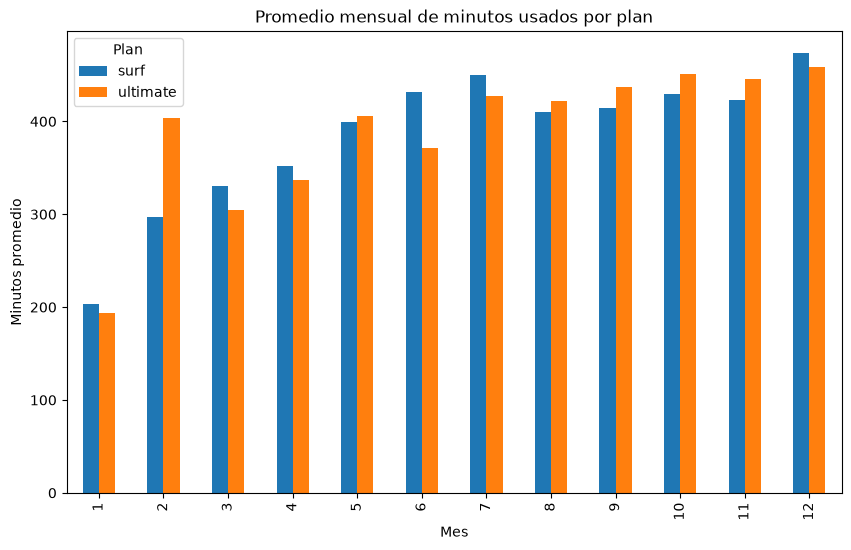

In [30]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

avg_minutes_by_plan_month = user_monthly_usage.groupby(['month', 'plan'])['minutes_used'].mean().reset_index()

avg_minutes_by_plan_month_pivot = avg_minutes_by_plan_month.pivot(
    index='month',
    columns='plan',
    values='minutes_used'
)

avg_minutes_by_plan_month_pivot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Promedio mensual de minutos usados por plan')
plt.xlabel('Mes')
plt.ylabel('Minutos promedio')
plt.legend(title='Plan')
plt.show()

La duración promedio mensual de llamadas muestra un comportamiento relativamente similar entre los usuarios de los planes `surf` y `ultimate`. Aunque en algunos meses uno de los planes supera al otro, no se observa una diferencia constante y marcada a favor de un solo plan. También se aprecia que el promedio de minutos tiende a ser mayor en los últimos meses del año.

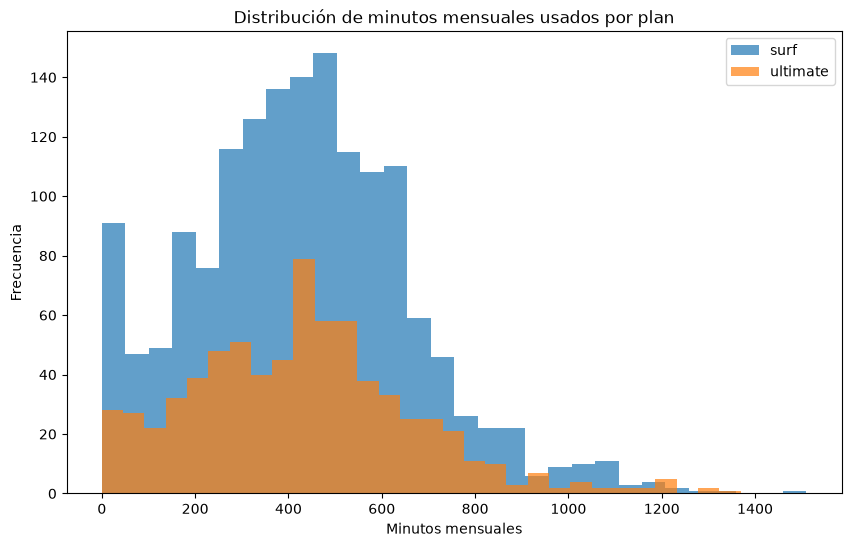

In [31]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

surf_minutes = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['minutes_used']
ultimate_minutes = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['minutes_used']

surf_minutes.plot(
    kind='hist',
    bins=30,
    alpha=0.7,
    figsize=(10, 6),
    label='surf'
)

ultimate_minutes.plot(
    kind='hist',
    bins=30,
    alpha=0.7,
    label='ultimate'
)

plt.title('Distribución de minutos mensuales usados por plan')
plt.xlabel('Minutos mensuales')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

El histograma muestra que la distribución de minutos mensuales usados por los usuarios de `surf` y `ultimate` es similar. En ambos planes, la mayoría de los registros se concentra aproximadamente entre 200 y 650 minutos mensuales. También se observan algunos valores altos por encima de 1000 minutos, lo que indica usuarios con consumo considerablemente mayor al promedio. Las frecuencias del plan `surf` son más altas, pero esto puede deberse a que hay más usuarios o registros mensuales de ese plan, no necesariamente a un mayor consumo individual.

In [32]:
# Calcula la media y la varianza de la duración mensual de llamadas.

surf_minutes_mean = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['minutes_used'].mean()
ultimate_minutes_mean = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['minutes_used'].mean()

surf_minutes_var = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['minutes_used'].var()
ultimate_minutes_var = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['minutes_used'].var()

call_duration_stats = pd.DataFrame({
    'plan': ['surf', 'ultimate'],
    'mean_minutes': [surf_minutes_mean, ultimate_minutes_mean],
    'variance_minutes': [surf_minutes_var, ultimate_minutes_var]
})

call_duration_stats

,plan,mean_minutes,variance_minutes
0,surf,428.749523,54968.279461
1,ultimate,430.450000,57844.464812


La media mensual de minutos usados es muy similar entre los usuarios de `surf` y `ultimate`: ambos planes están alrededor de 429 a 430 minutos mensuales. La varianza también es parecida, aunque ligeramente mayor en `ultimate`, lo que indica que el consumo de minutos de ese plan tiene una dispersión un poco más alta. En general, no se observa una diferencia marcada en el comportamiento de llamadas entre ambos planes.

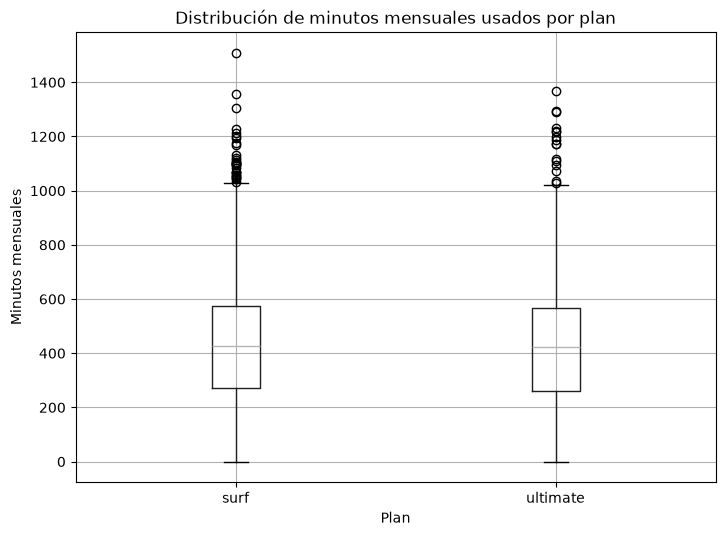

In [33]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

user_monthly_usage.boxplot(
    column='minutes_used',
    by='plan',
    figsize=(8, 6)
)

plt.title('Distribución de minutos mensuales usados por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales')
plt.show()


En general, el comportamiento de llamadas de los usuarios de `surf` y `ultimate` es muy similar. Las medias mensuales son casi iguales, alrededor de 429 a 430 minutos, y el diagrama de caja muestra medianas y rangos intercuartílicos muy parecidos. Ambos planes presentan algunos valores atípicos altos, con usuarios que superan los 1000 minutos mensuales. Con base en estos resultados, no se observa una diferencia marcada en el comportamiento de llamadas entre los usuarios de ambos planes.

### Mensajes

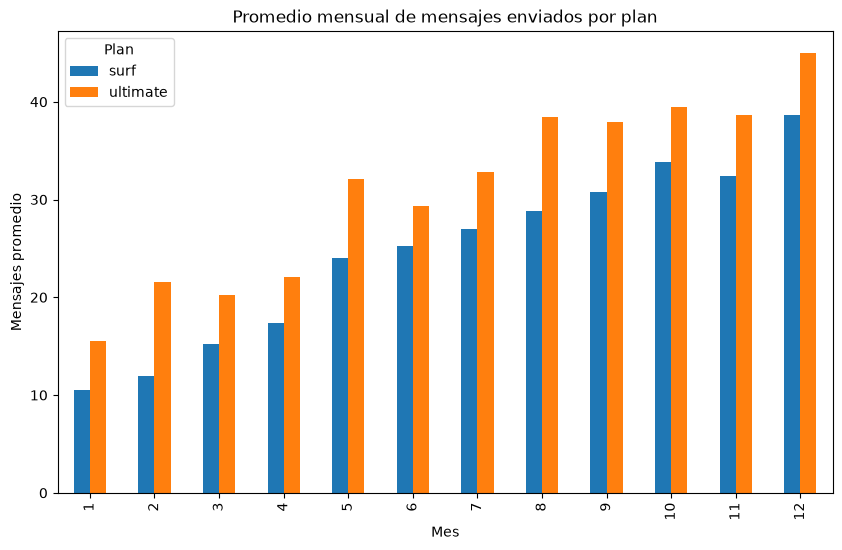

In [34]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

avg_messages_by_plan_month = user_monthly_usage.groupby(['month', 'plan'])['messages_count'].mean().reset_index()

avg_messages_by_plan_month_pivot = avg_messages_by_plan_month.pivot(
    index='month',
    columns='plan',
    values='messages_count'
)

avg_messages_by_plan_month_pivot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Promedio mensual de mensajes enviados por plan')
plt.xlabel('Mes')
plt.ylabel('Mensajes promedio')
plt.legend(title='Plan')
plt.show()


El promedio mensual de mensajes enviados tiende a ser mayor en el plan `ultimate` que en el plan `surf` durante prácticamente todos los meses. En ambos planes se observa un aumento gradual en el número promedio de mensajes enviados conforme avanza el año. A diferencia del comportamiento de llamadas, aquí sí parece haber una diferencia más consistente entre los planes.

In [35]:
# Calcula la media y la varianza de los mensajes mensuales enviados.

surf_messages_mean = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['messages_count'].mean()
ultimate_messages_mean = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['messages_count'].mean()

surf_messages_var = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['messages_count'].var()
ultimate_messages_var = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['messages_count'].var()

message_stats = pd.DataFrame({
    'plan': ['surf', 'ultimate'],
    'mean_messages': [surf_messages_mean, ultimate_messages_mean],
    'variance_messages': [surf_messages_var, ultimate_messages_var]
})

message_stats

,plan,mean_messages,variance_messages
0,surf,31.159568,1126.724522
1,ultimate,37.551389,1208.756744


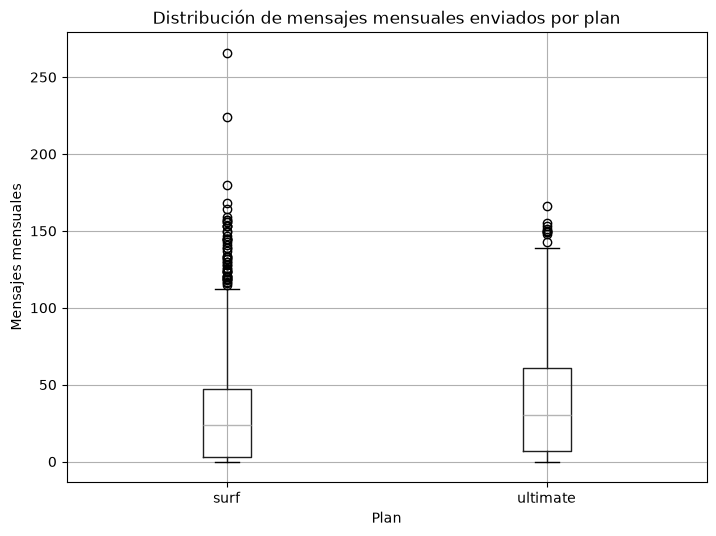

In [36]:
# Traza un diagrama de caja para visualizar la distribución de mensajes mensuales por plan

user_monthly_usage.boxplot(
    column='messages_count',
    by='plan',
    figsize=(8, 6)
)

plt.title('Distribución de mensajes mensuales enviados por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Mensajes mensuales')
plt.show()

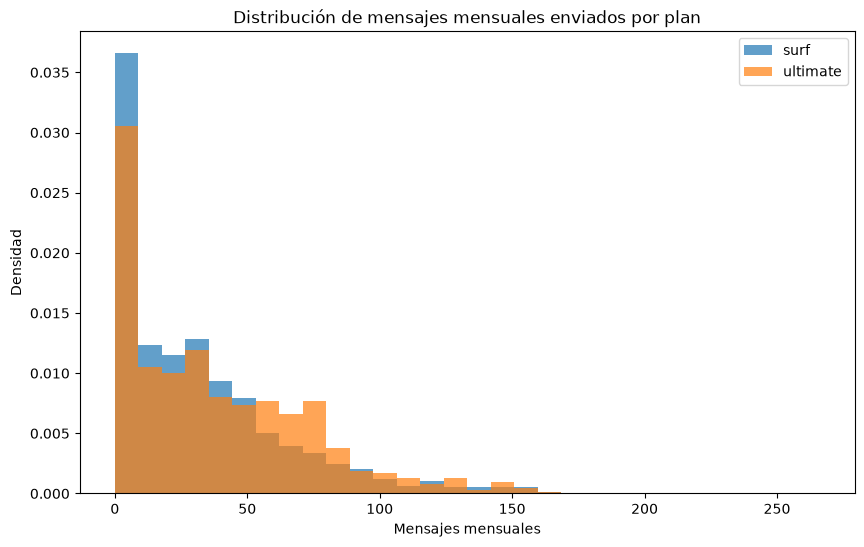

In [37]:
# Traza un histograma para visualizar la distribución de mensajes mensuales por plan

surf_messages = user_monthly_usage[
    user_monthly_usage['plan'] == 'surf'
]['messages_count']

ultimate_messages = user_monthly_usage[
    user_monthly_usage['plan'] == 'ultimate'
]['messages_count']

# Usar los mismos intervalos para ambos planes
bins = np.linspace(
    0,
    max(surf_messages.max(), ultimate_messages.max()),
    31
)

surf_messages.plot(
    kind='hist',
    bins=bins,
    density=True,
    alpha=0.7,
    figsize=(10, 6),
    label='surf'
)

ultimate_messages.plot(
    kind='hist',
    bins=bins,
    density=True,
    alpha=0.7,
    label='ultimate'
)

plt.title('Distribución de mensajes mensuales enviados por plan')
plt.xlabel('Mensajes mensuales')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Los usuarios de los planes `surf` y `ultimate` presentan patrones de uso de mensajes bastante similares. Aunque la media mensual de `ultimate` es ligeramente mayor, con aproximadamente 37.55 mensajes frente a 31.16 en `surf`, el histograma normalizado muestra que las distribuciones de ambos planes se superponen ampliamente.

En ambos casos se observa una distribución asimétrica hacia la derecha: la mayoría de los usuarios envía una cantidad relativamente baja o moderada de mensajes, mientras que existe un grupo menor con consumos considerablemente más altos. El diagrama de caja también refleja esta dispersión y la presencia de valores atípicos.

Por lo tanto, aunque `ultimate` presenta un promedio ligeramente superior, visualmente no se observa una diferencia marcada en el comportamiento de envío de mensajes entre ambos planes.

### Internet

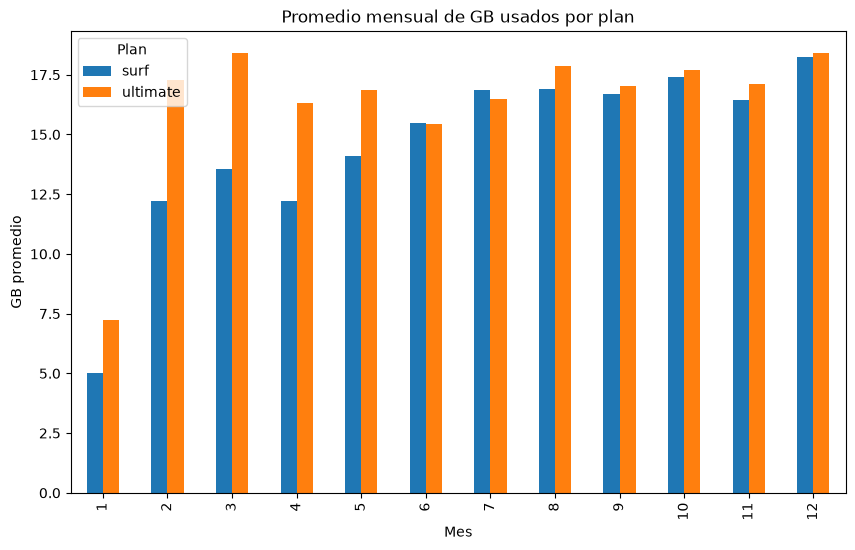

In [38]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan y por mes

avg_internet_by_plan_month = user_monthly_usage.groupby(['month', 'plan'])['gb_used'].mean().reset_index()

avg_internet_by_plan_month_pivot = avg_internet_by_plan_month.pivot(
    index='month',
    columns='plan',
    values='gb_used'
)

avg_internet_by_plan_month_pivot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Promedio mensual de GB usados por plan')
plt.xlabel('Mes')
plt.ylabel('GB promedio')
plt.legend(title='Plan')
plt.show()

El consumo promedio mensual de internet tiende a ser mayor en el plan `ultimate` que en el plan `surf`, especialmente durante los primeros meses del año. Sin embargo, en los meses posteriores la diferencia entre ambos planes se reduce y los consumos promedio se vuelven más similares. En ambos planes se observa una tendencia general de aumento en el consumo de datos conforme avanza el año.

In [39]:
# Calcula la media y la varianza del consumo mensual de internet.

surf_internet_mean = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['gb_used'].mean()
ultimate_internet_mean = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['gb_used'].mean()

surf_internet_var = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['gb_used'].var()
ultimate_internet_var = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['gb_used'].var()

internet_stats = pd.DataFrame({
    'plan': ['surf', 'ultimate'],
    'mean_gb': [surf_internet_mean, ultimate_internet_mean],
    'variance_gb': [surf_internet_var, ultimate_internet_var]
})

internet_stats

,plan,mean_gb,variance_gb
0,surf,16.670693,61.58360
1,ultimate,17.306944,58.83055


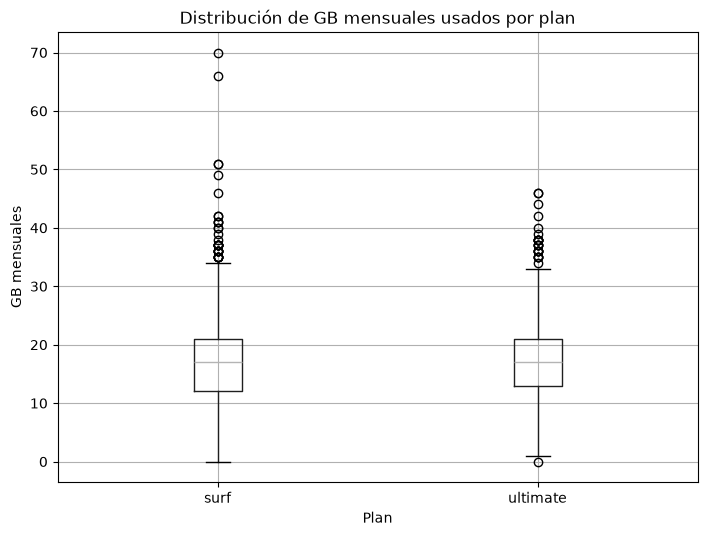

In [40]:
# Traza un diagrama de caja para visualizar la distribución del consumo mensual de internet por plan

user_monthly_usage.boxplot(
    column='gb_used',
    by='plan',
    figsize=(8, 6)
)

plt.title('Distribución de GB mensuales usados por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('GB mensuales')
plt.show()

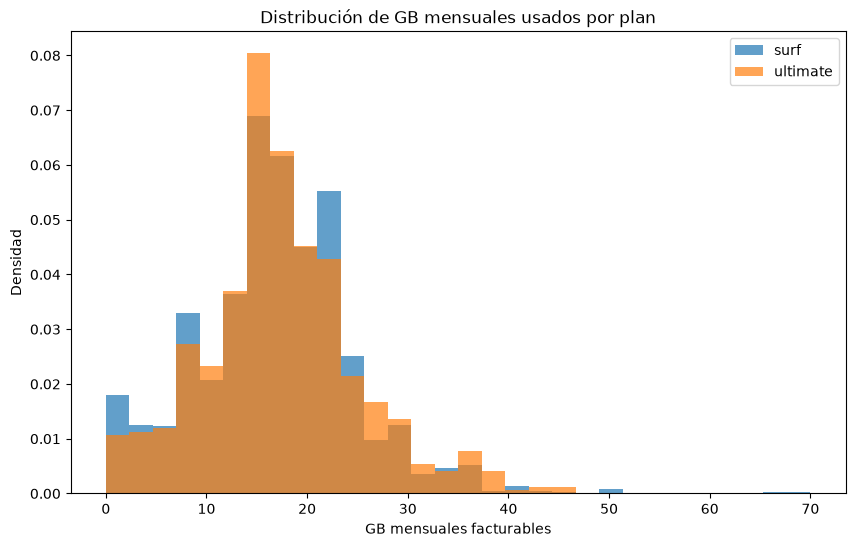

In [41]:
# Traza un histograma para visualizar la distribución del consumo mensual
# facturable de internet por plan

surf_internet = user_monthly_usage[
    user_monthly_usage['plan'] == 'surf'
]['gb_used']

ultimate_internet = user_monthly_usage[
    user_monthly_usage['plan'] == 'ultimate'
]['gb_used']

# Usar los mismos intervalos para ambos planes
bins = np.linspace(
    0,
    max(surf_internet.max(), ultimate_internet.max()),
    31
)

surf_internet.plot(
    kind='hist',
    bins=bins,
    density=True,
    alpha=0.7,
    figsize=(10, 6),
    label='surf'
)

ultimate_internet.plot(
    kind='hist',
    bins=bins,
    density=True,
    alpha=0.7,
    label='ultimate'
)

plt.title('Distribución de GB mensuales usados por plan')
plt.xlabel('GB mensuales facturables')
plt.ylabel('Densidad')
plt.legend()
plt.show()

El consumo mensual facturable de internet es muy similar entre los usuarios de los planes `surf` y `ultimate`. Las medias también son cercanas: aproximadamente 16.67 GB para `surf` y 17.31 GB para `ultimate`.

El histograma normalizado muestra una amplia superposición entre ambas distribuciones. La mayor parte de los usuarios de los dos planes se concentra aproximadamente en los mismos rangos de consumo, por lo que visualmente no se observa una diferencia marcada en su comportamiento de uso de internet.

Ambas distribuciones presentan cierta dispersión hacia consumos más altos y algunos valores atípicos. En particular, `surf` presenta algún consumo extremo mayor que `ultimate`, aunque estos casos son poco frecuentes y no representan el comportamiento general de los usuarios.

En conjunto, el consumo de internet de ambos planes es muy parecido. Sin embargo, esta variable es especialmente relevante para los ingresos, ya que `surf` incluye 15 GB mensuales, mientras que `ultimate` incluye 30 GB; por lo tanto, consumos similares pueden producir cargos adicionales con mayor frecuencia en el plan `surf`.

## Ingreso

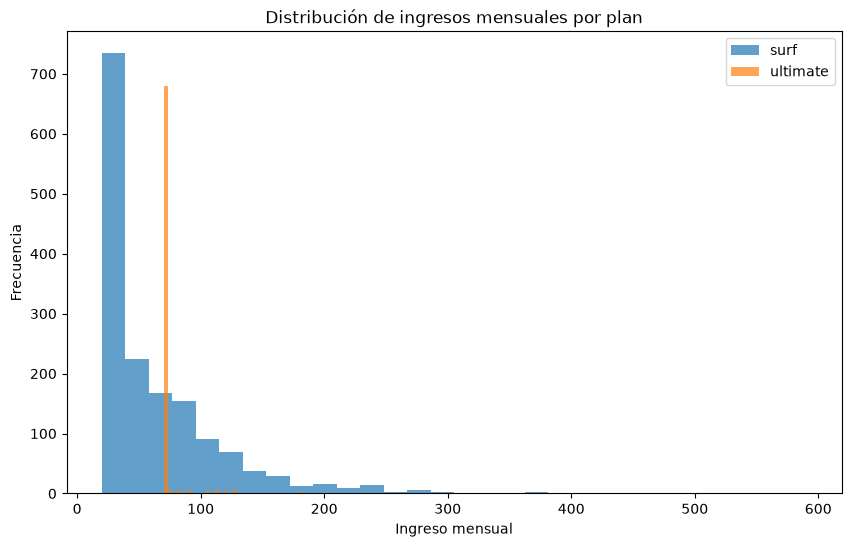

In [42]:
# Traza un histograma para visualizar la distribución de ingresos mensuales por plan

surf_revenue = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['monthly_revenue']

surf_revenue.plot(
    kind='hist',
    bins=30,
    alpha=0.7,
    figsize=(10, 6),
    label='surf'
)

ultimate_revenue.plot(
    kind='hist',
    bins=30,
    alpha=0.7,
    label='ultimate'
)

plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso mensual')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [43]:
# Describe estadísticamente los ingresos mensuales por plan.

surf_revenue_mean = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['monthly_revenue'].mean()
ultimate_revenue_mean = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['monthly_revenue'].mean()

surf_revenue_var = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['monthly_revenue'].var()
ultimate_revenue_var = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['monthly_revenue'].var()

revenue_stats = pd.DataFrame({
    'plan': ['surf', 'ultimate'],
    'mean_revenue': [surf_revenue_mean, ultimate_revenue_mean],
    'variance_revenue': [surf_revenue_var, ultimate_revenue_var]
})

revenue_stats

,plan,mean_revenue,variance_revenue
0,surf,60.706408,3067.835152
1,ultimate,72.313889,129.848486


In [44]:
# Revisar los ingresos mensuales más frecuentes en el plan ultimate

user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['monthly_revenue'].value_counts().head(10)

monthly_revenue
70.0     679
91.0       6
126.0      6
112.0      5
77.0       5
84.0       4
119.0      4
105.0      4
182.0      2
140.0      1
Name: count, dtype: int64

La distribución de ingresos del plan `ultimate` está fuertemente concentrada en 70 USD, que corresponde a la cuota mensual base. Esto confirma que la mayoría de los usuarios de este plan no generan cargos adicionales, ya que los límites incluidos son suficientemente altos para cubrir su consumo mensual. Los pocos valores superiores a 70 representan casos con excedentes.

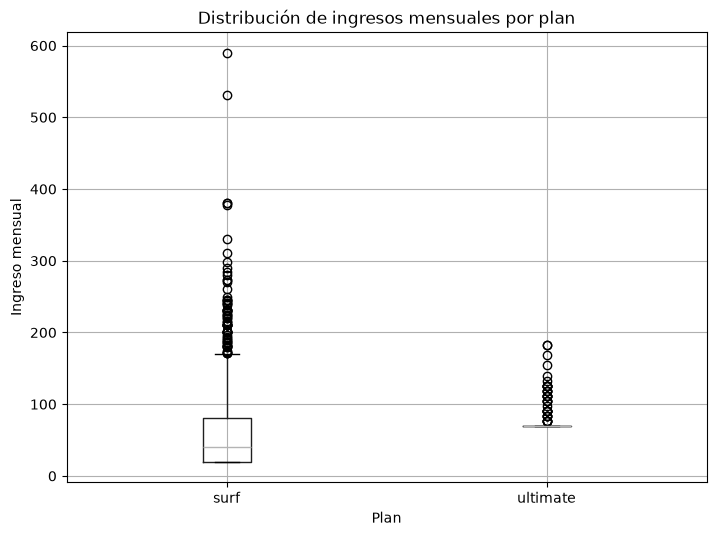

In [45]:
# Traza un diagrama de caja para visualizar la distribución de ingresos mensuales por plan

user_monthly_usage.boxplot(
    column='monthly_revenue',
    by='plan',
    figsize=(8, 6)
)

plt.title('Distribución de ingresos mensuales por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Ingreso mensual')
plt.show()

El plan `ultimate` genera un ingreso mensual promedio mayor que `surf`: aproximadamente 72.31 USD frente a 60.71 USD. Sin embargo, la distribución de ingresos es muy diferente entre ambos planes. En `ultimate`, la mayoría de los usuarios paga cerca de 70 USD, que corresponde a la cuota mensual base, por lo que los ingresos son más estables y tienen una varianza baja. En cambio, `surf` tiene una cuota base menor, pero muchos usuarios generan cargos adicionales, especialmente por excedentes de internet. Esto produce una distribución mucho más dispersa y con valores atípicos altos. En resumen, `ultimate` genera más ingreso promedio y es más estable, mientras que `surf` depende más de los cargos por excedente.

## Prueba las hipótesis estadísticas

Hipótesis nula: el ingreso promedio mensual de los usuarios de `ultimate` es igual al ingreso promedio mensual de los usuarios de `surf`.

Hipótesis alternativa: el ingreso promedio mensual de los usuarios de `ultimate` es diferente al ingreso promedio mensual de los usuarios de `surf`.

Se utilizará una prueba t bilateral para dos muestras independientes, ya que se comparan los ingresos de dos grupos distintos de usuarios. Como las varianzas de ingresos entre los planes son diferentes, se utilizará la versión de Welch mediante `equal_var=False`. El nivel de significancia será de 0.05.

In [46]:
# Prueba las hipótesis

alpha = 0.05

surf_revenue = user_monthly_usage[user_monthly_usage['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = user_monthly_usage[user_monthly_usage['plan'] == 'ultimate']['monthly_revenue']

results = st.ttest_ind(
    surf_revenue,
    ultimate_revenue,
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

p-value: 3.170390548113581e-15
Rechazamos la hipótesis nula


El valor p obtenido fue mucho menor que el nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula. Esto indica que existe evidencia estadística suficiente para concluir que el ingreso promedio mensual de los usuarios de `surf` y `ultimate` es diferente. Además, de acuerdo con las medias calculadas previamente, el plan `ultimate` genera un ingreso promedio mensual mayor que el plan `surf`.

In [47]:
# Revisar cuántos registros hay en cada grupo regional

user_monthly_usage['region_group'].value_counts()

region_group
Other    1916
NY-NJ     377
Name: count, dtype: int64

Hipótesis nula: el ingreso promedio mensual de los usuarios del área NY-NJ es igual al ingreso promedio mensual de los usuarios de otras regiones.

Hipótesis alternativa: el ingreso promedio mensual de los usuarios del área NY-NJ es diferente al ingreso promedio mensual de los usuarios de otras regiones.

Se utilizará una prueba t bilateral para dos muestras independientes, ya que se comparan los ingresos de dos grupos regionales distintos. Como no se asume igualdad de varianzas entre los grupos y los tamaños de muestra son diferentes, se utilizará la versión de Welch mediante `equal_var=False`. El nivel de significancia será de 0.05.

In [48]:
# Prueba las hipótesis

alpha = 0.05

ny_nj_revenue = user_monthly_usage[user_monthly_usage['region_group'] == 'NY-NJ']['monthly_revenue']
other_revenue = user_monthly_usage[user_monthly_usage['region_group'] == 'Other']['monthly_revenue']

results = st.ttest_ind(
    ny_nj_revenue,
    other_revenue,
    equal_var=False
)

print('Ingreso promedio NY-NJ:', ny_nj_revenue.mean())
print('Ingreso promedio otras regiones:', other_revenue.mean())
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Ingreso promedio NY-NJ: 59.921352785145885
Ingreso promedio otras regiones: 65.2227713987474
p-value: 0.03352561588530015
Rechazamos la hipótesis nula


El valor p obtenido fue 0.0335, menor que el nivel de significancia de 0.05. Por lo tanto, se rechaza la hipótesis nula. Esto indica que existe evidencia estadística suficiente para concluir que el ingreso promedio mensual de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones. Además, las medias calculadas muestran que el ingreso promedio mensual de otras regiones es mayor que el de NY-NJ en esta muestra.

## Conclusión general

En este proyecto se analizaron los datos de usuarios de Megaline para comparar el comportamiento de consumo y los ingresos generados por los planes `surf` y `ultimate`.

Durante la preparación de los datos se tomaron las siguientes decisiones importantes:

- Las columnas de fecha en las tablas de usuarios, llamadas, mensajes e internet se convirtieron al tipo `datetime`.
- Los valores ausentes en `churn_date` se conservaron, ya que representan usuarios que seguían activos al momento de extraer los datos.
- Se revisaron las llamadas con duración igual a cero o negativa. Las llamadas con duración cero se conservaron porque pueden representar llamadas realizadas sin minutos facturables, mientras que no se identificaron duraciones negativas.
- Las llamadas se redondearon hacia arriba de forma individual para calcular los minutos facturables, de acuerdo con la regla de facturación de Megaline.
- El consumo de internet se agregó primero por usuario y mes en MB y posteriormente se convirtió a GB redondeados hacia arriba, ya que la facturación se realiza sobre el consumo mensual total.
- Los valores ausentes en los consumos mensuales de llamadas, mensajes o internet se reemplazaron por 0, ya que indican que el usuario no utilizó ese servicio durante ese mes.
- Se creó una clasificación regional `NY-NJ` vs `Other` a partir de la columna `city` para realizar la segunda prueba de hipótesis.

En cuanto al comportamiento de los usuarios, el consumo de llamadas fue muy similar entre ambos planes, con promedios mensuales cercanos a 429 minutos para `surf` y 430 minutos para `ultimate`.

En mensajes, `ultimate` presentó una media mensual ligeramente mayor, aproximadamente 37.55 mensajes frente a 31.16 de `surf`. Sin embargo, el análisis de las distribuciones mostró una amplia superposición entre ambos planes, por lo que visualmente no se observa una diferencia marcada en el comportamiento de envío de mensajes.

El consumo mensual de internet también fue muy parecido entre ambos planes. Las medias fueron aproximadamente 16.67 GB para `surf` y 17.31 GB para `ultimate`, y las distribuciones mostraron una amplia superposición. Esto indica que los patrones generales de consumo de internet son similares.

La diferencia más importante apareció en los ingresos. El plan `ultimate` generó un ingreso promedio mensual mayor, con aproximadamente 72.31 USD frente a 60.71 USD de `surf`. Además, los ingresos de `ultimate` fueron más estables, mientras que `surf` presentó una dispersión mayor debido a los cargos adicionales generados cuando los usuarios excedieron los límites incluidos en su tarifa, especialmente en el consumo de internet.

La primera prueba de hipótesis mostró que el ingreso promedio mensual de los usuarios de `surf` y `ultimate` es diferente. El valor p fue mucho menor que el nivel de significancia de 0.05, por lo que se rechazó la hipótesis nula. Las medias calculadas indican además que `ultimate` genera un ingreso promedio mensual mayor.

La segunda prueba de hipótesis comparó el ingreso promedio mensual de los usuarios del área NY-NJ con el de los usuarios de otras regiones. El valor p fue aproximadamente 0.0335, menor que el nivel de significancia de 0.05, por lo que también se rechazó la hipótesis nula. En esta muestra, el ingreso promedio mensual de los usuarios de otras regiones fue mayor que el de NY-NJ: aproximadamente 65.22 USD frente a 59.92 USD.

Con base en estos resultados, si el objetivo del departamento comercial es ajustar el presupuesto de publicidad hacia la tarifa que genera un mayor ingreso promedio, el plan `ultimate` debería recibir mayor prioridad publicitaria. Este plan genera un ingreso promedio mensual mayor y presenta ingresos más estables.

Sin embargo, `surf` no debe descartarse por completo. Aunque su cuota mensual es menor, algunos usuarios generan cargos adicionales cuando exceden los servicios incluidos, particularmente los 15 GB mensuales de internet. Por ello, una estrategia razonable sería priorizar `ultimate` en campañas generales y considerar estrategias específicas para usuarios de alto consumo.